# Fully Connected Neural Network

- **Name：？？？？？？？**

- **Student ID：？？？？？？？**

## Objectives

In this assignment, you will build a Fully Connected Neural Network using the PyTorch framework through **prompt programming** to perform image classification on the CIFAR10 dataset. By completing this assignment, you will:

1. Learn how to load and visualize the CIFAR10 dataset
2. Understand the architectural design of fully connected neural networks (linear layers, batch normalization, activation functions)
3. Implement the model training pipeline (forward propagation, loss computation, backpropagation, parameter updates)
4. Evaluate model performance using confusion matrices and classification reports
5. Interpret learned features through weight visualization

### Instructions

Each code cell is preceded by a **prompt**. Enter the prompt into an AI programming tool (e.g., ChatGPT, Claude, GitHub Copilot), then paste the generated code into the corresponding cell and run it.

---

## 1. Environment Setup

**Prompt**

Help me set up the Python environment for a deep learning experiment:
1. Import `matplotlib.pyplot` and `matplotlib`
2. Configure matplotlib for proper display:
   - Set `plt.rcParams['figure.dpi'] = 100` for clear figure resolution
   - Set `plt.rcParams['axes.unicode_minus'] = False` to fix minus sign display issues

In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Configure matplotlib display settings
plt.rcParams['figure.dpi'] = 100  # High resolution figures
plt.rcParams['axes.unicode_minus'] = False  # Fix minus sign display

## 2. CIFAR10 Dataset Loading and Exploration

**Prompt**

Using the PyTorch framework, load the CIFAR10 dataset and visualize sample images. Requirements:

**1. Import required libraries:**
- `torch`, `torch.nn`, `torchvision.transforms`, `torch.utils.data.DataLoader`
- `torchvision.datasets`
- `numpy`, `matplotlib.pyplot`, `time`
- From `sklearn.metrics`: `confusion_matrix`, `classification_report`, `precision_recall_fscore_support`, `accuracy_score`
- `seaborn`

**2. Set global parameters:**
- Data path: `data_path = './data'`
- Batch size: `batch_size = 32`
- Number of epochs: `num_epochs = 20`

**3. Define data preprocessing:**
- Use `transforms.Compose` to combine the following transformations:
  - `transforms.ToTensor()`: convert images to tensors
  - `transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])`: normalize pixel values to [-1, 1]

**4. Load the datasets:**
- Training set: `torchvision.datasets.CIFAR10(root=data_path, train=True, transform=transform, download=True)`
- Test set: `torchvision.datasets.CIFAR10(root=data_path, train=False, transform=transform, download=True)`
- Create DataLoaders with `batch_size=batch_size`, training set `shuffle=True`, test set `shuffle=False`, `num_workers=2`

**5. Define CIFAR10 class names:**
- `classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')`

**6. Implement the image display function `imshow(img)`:**
- Parameter `img` is a `torch.Tensor` with shape (C, H, W)
- Denormalize: `img = img / 2 + 0.5`
- Convert to numpy array using `.numpy()`, then reorder dimensions from (C,H,W) to (H,W,C) using `np.transpose(npimg, (1, 2, 0))`
- Display using `plt.imshow`, turn off axis

**7. Visualize sample images:**
- Get the first batch from the training DataLoader using `next(iter(trainloader))`
- Create a 2×2 subplot grid using `plt.subplots(2, 2)`
- Display 4 images, each titled with its class name (use `classes[labels[i].item()]`)
- Use `plt.tight_layout()` to adjust layout

**8. Print dataset information:**
- Class names of the first 4 images
- Training set size: `len(trainset)`
- Test set size: `len(testset)`
- Image dimensions: `trainset[0][0].shape`

100.0%


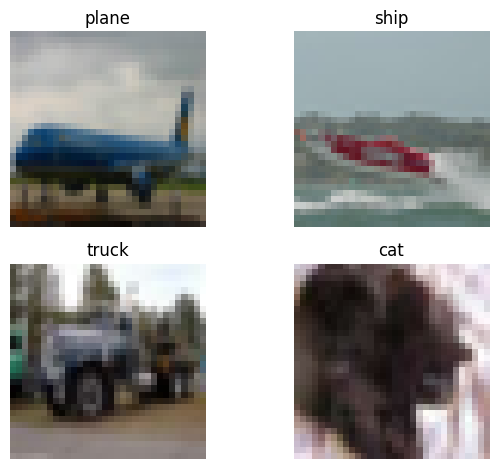

plane ship  truck cat  
Training set size: 50000
Test set size: 10000
Image dimensions: torch.Size([3, 32, 32])


In [2]:
# Import required libraries (PyTorch version)
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support, accuracy_score
import seaborn as sns

# Set dataset download path
data_path = './data'
batch_size = 32
num_epochs = 20

# Define data transformations
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Download and load training set
trainset = datasets.CIFAR10(
    root=data_path,
    train=True,
    transform=transform,
    download=True)

trainloader = DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2)

# Download and load test set
testset = datasets.CIFAR10(
    root=data_path,
    train=False,
    transform=transform,
    download=True)

testloader = DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2)

# CIFAR10 class names
classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

# Image display function (PyTorch version)
def imshow(img):
    """
    Display a PyTorch tensor as an image
    Args:
        img: torch.Tensor with shape (C, H, W)
    """
    img = img / 2 + 0.5  # Denormalize
    npimg = img.numpy()
    # Reorder dimensions to (H, W, C)
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')
    plt.show()

# Get a batch of training images
images, labels = next(iter(trainloader))

# Create a 2x2 image grid
fig, axes = plt.subplots(2, 2)
for i in range(4):
    row, col = i // 2, i % 2
    img = images[i]
    # Preprocess for display
    img = img / 2 + 0.5  # Denormalize
    npimg = img.numpy()
    npimg = np.transpose(npimg, (1, 2, 0))  # CHW -> HWC
    
    axes[row, col].imshow(npimg)
    axes[row, col].set_title(classes[labels[i].item()])
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Print label information
print(' '.join(f'{classes[labels[j].item()]:5s}' for j in range(4)))

# Print dataset information
print(f'Training set size: {len(trainset)}')
print(f'Test set size: {len(testset)}')
print(f'Image dimensions: {trainset[0][0].shape}')

## 3. Fully Connected Neural Network Design

### 3.1 Random Seeds and Compute Device

**Prompt**

Using PyTorch, set random seeds and check the compute device. Requirements:
1. Set random seeds for reproducibility: `torch.manual_seed(42)` and `np.random.seed(42)`
2. Also set `torch.cuda.manual_seed(42)` if CUDA is available
3. Detect the compute device: use `torch.device('cuda' if torch.cuda.is_available() else 'cpu')`, assign to variable `device`
4. Print the device info: `f"Using device: {device}"`

In [3]:
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Check for available GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### 3.2 Network Architecture Definition

**Prompt**

Using PyTorch, create a fully connected neural network class with the following requirements:

**1. Class definition:**
- Class name: `FCNet`, inheriting from `nn.Module`

**2. Network architecture: 4 fully connected layers with the following dimensions:**
- `fc1`: 3072 → 1024
- `fc2`: 1024 → 512
- `fc3`: 512 → 256
- `fc4`: 256 → 10

**3. Layer structure (except the last layer):**
- Linear layer (`nn.Linear`) → Batch Normalization (`nn.BatchNorm1d`) → ReLU activation (`nn.ReLU`)
- The last layer has only a Linear layer + Softmax activation (`nn.Softmax`)

**4. Weight initialization (at the end of `__init__`):**
- Iterate over `self.modules()`, and for each `nn.Linear` layer:
  - Initialize weights using `nn.init.kaiming_normal_` (He initialization)
  - Initialize biases to 0 using `nn.init.constant_(layer.bias, 0.0)`

**5. Forward propagation `forward(self, x)`:**
- First flatten the input using `torch.flatten(x, 1)` (preserving the batch dimension)
- Pass through layers sequentially: `fc1 → bn1 → relu → fc2 → bn2 → relu → fc3 → bn3 → relu → fc4 → softmax`
- Return the output

**Think about it:** Why is the input dimension 3072? Hint: The CIFAR10 image size is 3×32×32. Why doesn't the last layer need batch normalization and ReLU?

In [ ]:
#TODO: add your code here

### 3.3 Model Instantiation

**Prompt**

Instantiate the FCNet model and print its architecture. Requirements:
1. Create an `FCNet()` instance and move it to the compute device using `.to(device)`
2. Assign the model to variable `model`
3. Print the model architecture using `print(model)` to confirm the layer dimensions and parameters

In [5]:
# Instantiate the model
model = FCNet().to(device)
print(model)

FCNet(
  (fc1): Linear(in_features=3072, out_features=1024, bias=True)
  (bn1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=512, out_features=256, bias=True)
  (bn3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc4): Linear(in_features=256, out_features=10, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
)


## 4. Model Training

### 4.1 Loss Function and Optimizer

**Prompt**

Define the loss function and optimizer for model training. Requirements:
1. Loss function: use `nn.CrossEntropyLoss()` (cross-entropy loss), assign to variable `criterion`
2. Optimizer: use `torch.optim.Adam` with learning rate `0.001` and `model.parameters()` as the parameter group, assign to variable `optimizer`

**Note:** `CrossEntropyLoss` internally applies Softmax to its input, so it expects raw logits rather than Softmax-normalized probabilities. If your network's last layer already applies Softmax, this may affect training performance — we will investigate this later in the experiment.

In [6]:
# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()  # Cross-entropy loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)  # Adam optimizer, learning rate 0.001

### 4.2 Training Function

**Prompt**

Using PyTorch, create a model training function with the following requirements:

**1. Function definition:** `train_model(epochs=10)`

**2. Initialization inside the function:**
- Create an `FCNet()` instance and move it to device using `.to(device)`, assign to `model`
- Define loss function: `nn.CrossEntropyLoss()`, assign to `criterion`
- Define optimizer: `torch.optim.Adam(model.parameters(), lr=0.001)`, assign to `optimizer`
- Create empty lists `train_loss` and `train_accs` to record per-epoch loss and accuracy

**3. Training loop:**
- Outer loop: `for epoch in range(epochs)`
- Per-epoch initialization: `total_loss = 0`, `total_correct = 0`, `total_samples = 0`
- Call `model.train()` to set training mode

**4. Inner loop (iterating over training data):**
- `for batch_id, data in enumerate(trainloader)` (note: in PyTorch, DataLoader is directly iterable — no parentheses needed)
- Unpack data: `images, labels = data`
- Move data to device: `images = images.to(device)`, `labels = labels.to(device)`
- Forward pass: `outputs = model(images)`
- Compute loss: `loss = criterion(outputs, labels)`
- Backward pass: `optimizer.zero_grad()` then `loss.backward()` then `optimizer.step()`
- Compute correct predictions in this batch: `pred = outputs.argmax(dim=1)`, then `correct = (pred == labels).float().sum().item()`
- Accumulate `total_correct`, `total_samples`, `total_loss`

**5. At the end of each epoch:**
- Compute average loss: `avg_loss = total_loss / len(trainloader)`
- Compute average accuracy: `avg_acc = total_correct / total_samples`
- Append `avg_loss` and `avg_acc` to the `train_loss` and `train_accs` lists respectively
- Print: `f"Epoch {epoch+1}, Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.4f}"`

**6. Return:** `train_loss, train_accs, model` (list of training losses, list of accuracies, the trained model)

In [ ]:
# TODO: add your code here

### 4.3 Execute Training

**Prompt**

Call the training function to start model training. Requirements:
1. Call `train_model(epochs=num_epochs)` to start training
2. Assign the return values to `train_losses`, `train_accs`, `model` respectively

**Note:** Training may take several minutes. Please be patient and observe the loss and accuracy changes at each epoch.

In [8]:
# Train the model
train_losses, train_accs, model = train_model(epochs=num_epochs)

Epoch 1, Loss: 2.0970, Accuracy: 0.3562
Epoch 2, Loss: 2.0420, Accuracy: 0.4135
Epoch 3, Loss: 2.0127, Accuracy: 0.4435
Epoch 4, Loss: 1.9962, Accuracy: 0.4605
Epoch 5, Loss: 1.9779, Accuracy: 0.4788
Epoch 6, Loss: 1.9660, Accuracy: 0.4902
Epoch 7, Loss: 1.9517, Accuracy: 0.5053
Epoch 8, Loss: 1.9429, Accuracy: 0.5152
Epoch 9, Loss: 1.9330, Accuracy: 0.5251
Epoch 10, Loss: 1.9235, Accuracy: 0.5340
Epoch 11, Loss: 1.9150, Accuracy: 0.5423
Epoch 12, Loss: 1.9059, Accuracy: 0.5527
Epoch 13, Loss: 1.8982, Accuracy: 0.5600
Epoch 14, Loss: 1.8920, Accuracy: 0.5656
Epoch 15, Loss: 1.8869, Accuracy: 0.5726
Epoch 16, Loss: 1.8789, Accuracy: 0.5800
Epoch 17, Loss: 1.8702, Accuracy: 0.5878
Epoch 18, Loss: 1.8675, Accuracy: 0.5912
Epoch 19, Loss: 1.8589, Accuracy: 0.6000
Epoch 20, Loss: 1.8524, Accuracy: 0.6072


### 4.4 Training Process Visualization

**Prompt**

Plot the training loss and accuracy curves. Requirements:
1. Create a figure with `figsize=(12, 5)`
2. Left subplot `plt.subplot(1, 2, 1)`:
   - Plot `train_losses`
   - Title: `'Training Loss'`
   - x-axis label: `'Epoch'`, y-axis label: `'Loss'`
3. Right subplot `plt.subplot(1, 2, 2)`:
   - Plot `train_accs`
   - Title: `'Training Accuracy'`
   - x-axis label: `'Epoch'`, y-axis label: `'Accuracy (%)'`
4. Use `plt.tight_layout()` to adjust layout and prevent overlap

**Think about it:** Observe the training curves — is the loss consistently decreasing? Is the accuracy consistently increasing? Has the training converged? Do you think 20 epochs is sufficient?

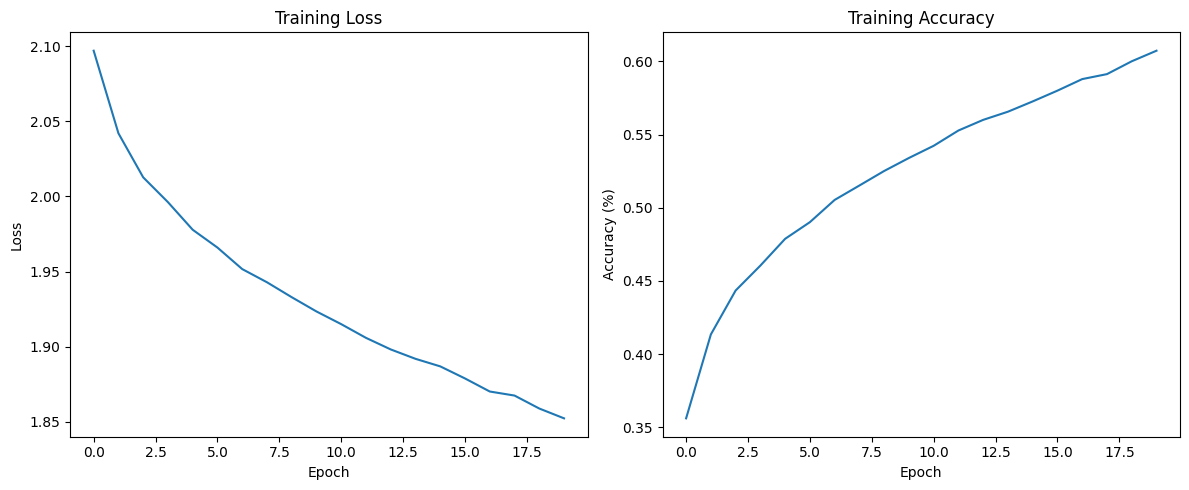

In [9]:
# Plot training loss and accuracy
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(train_accs)
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')

plt.tight_layout()
plt.show()

## 5. Model Evaluation

**Prompt**

Using PyTorch, write a model evaluation function to comprehensively assess classification performance on the test set. Requirements:

**1. Function definition:** `evaluate_model(model)`, parameter is the trained model object, no return value

**2. Evaluation workflow:**
- Call `model.eval()` to enter evaluation mode (disables Dropout and freezes BatchNorm)
- Create two empty lists `all_labels` and `all_preds` to store all ground truth and predicted labels
- Use `with torch.no_grad():` to disable gradient computation and save memory
- Iterate over `testloader` to get each batch of data
- Unpack data: `images, labels = data`
- Move data to device: `images = images.to(device)`, `labels = labels.to(device)`
- Forward pass: `outputs = model(images)`
- Get predicted classes: `pred = outputs.argmax(dim=1)`
- Extend `all_labels` with `labels.cpu().numpy()` and `all_preds` with `pred.cpu().numpy()`

**3. Confusion matrix visualization:**
- Compute confusion matrix using `sklearn.metrics.confusion_matrix(all_labels, all_preds)`
- Plot heatmap using `seaborn.heatmap`:
  - Figure size: `figsize=(10, 8)`
  - Parameters: `annot=True` (show values), `fmt='d'` (integer format), `cmap='Blues'`
  - x-axis tick labels: `list(classes)` (the CIFAR10 class names)
  - y-axis tick labels: same as above
  - Title: `'Confusion Matrix'`
  - x-axis label: `'Predicted Label'`, y-axis label: `'True Label'`

**4. Classification report:**
- Generate a report with precision/recall/f1 using `sklearn.metrics.classification_report(all_labels, all_preds, target_names=list(classes))`
- Print the report

**5. Accuracy statistics:**
- Compute overall accuracy: `overall_accuracy = np.sum(np.diag(cm)) / np.sum(cm)`, and print it
- Compute per-class accuracy: `class_accuracy[i] = cm[i,i] / np.sum(cm[i,:])` (handle division by zero), print each class accuracy

In [10]:
def evaluate_model(model):
    # Evaluation mode
    model.eval()
    all_labels = []
    all_preds = []
    
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            pred = outputs.argmax(dim=1)
            
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(pred.cpu().numpy())
    
    # Compute and visualize confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(classes),
                yticklabels=list(classes))
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.show()
    
    # Classification report (precision, recall, f1-score)
    report = classification_report(all_labels, all_preds, target_names=list(classes))
    print("Classification Report:")
    print(report)
    
    # Compute overall accuracy and per-class accuracy
    overall_accuracy = np.sum(np.diag(cm)) / np.sum(cm)
    print(f"Overall Accuracy: {overall_accuracy:.4f}")
    
    class_accuracy = {}
    for i in range(10):
        class_accuracy[i] = cm[i,i] / np.sum(cm[i,:]) if np.sum(cm[i,:]) > 0 else 0
        print(f"Class {classes[i]} Accuracy: {class_accuracy[i]:.4f}")
    
    return

**Prompt**

Call the evaluation function to assess the trained model on the test set:
1. Call `evaluate_model(model)`

**Think about it:** The test accuracy of the fully connected network on CIFAR10 is around 50% — far below human recognition ability. Why does the fully connected network perform poorly on image classification tasks? What limitations of fully connected networks does this reflect? (Hint: Consider how spatial structure information in images is processed)

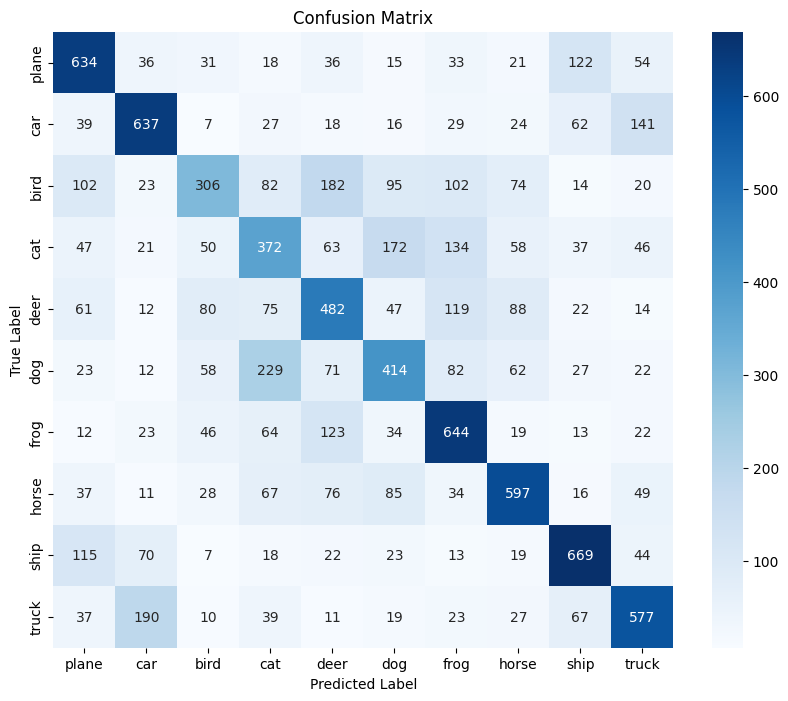

Classification Report:
              precision    recall  f1-score   support

       plane       0.57      0.63      0.60      1000
         car       0.62      0.64      0.63      1000
        bird       0.49      0.31      0.38      1000
         cat       0.38      0.37      0.37      1000
        deer       0.44      0.48      0.46      1000
         dog       0.45      0.41      0.43      1000
        frog       0.53      0.64      0.58      1000
       horse       0.60      0.60      0.60      1000
        ship       0.64      0.67      0.65      1000
       truck       0.58      0.58      0.58      1000

    accuracy                           0.53     10000
   macro avg       0.53      0.53      0.53     10000
weighted avg       0.53      0.53      0.53     10000

Overall Accuracy: 0.5332
Class plane Accuracy: 0.6340
Class car Accuracy: 0.6370
Class bird Accuracy: 0.3060
Class cat Accuracy: 0.3720
Class deer Accuracy: 0.4820
Class dog Accuracy: 0.4140
Class frog Accuracy: 0.6440

In [11]:
# Evaluate the model
evaluate_model(model)

## 6. Weight Visualization

**Prompt**

Using PyTorch and Matplotlib, implement a weight visualization function to help understand the features learned by the network. Requirements:

**1. Function definition:** `visualize_weights(model)`, parameter is the trained model

**2. Get weights:**
- Get the weight matrix of the output layer (fc4): `weights = model.fc4.weight.detach().cpu().numpy().T`
- Transpose so that each column corresponds to one output neuron's weights
- `.detach()` is needed to detach from the computation graph before converting to numpy

**3. Visualization layout:**
- Create a figure with `figsize=(15, 10)`
- Use `plt.subplot(2, 5, i+1)` to create a 2×5 grid of 10 subplots (one per class)

**4. Content of each subplot:**
- Reshape the weights of the i-th output neuron into a 16×16 image: `weights[i].reshape(16, 16)`
  (because fc4's input dimension is 256 = 16 × 16)
- Display using `plt.imshow(weight_img, cmap='viridis')`
- Title: `f'Class {i} Weights'`
- Turn off axis: `plt.axis('off')`

**5. Layout adjustment:**
- Use `plt.tight_layout()` to adjust layout
- Print: `"Weight visualization complete"`

**Think about it:** Observe the weight visualization results. What features do the weight images of different classes show? What do the color intensities represent? Can you discern any patterns the network has learned? Why are these weight images blurry and difficult to interpret?

In [ ]:
#TODO: add your code here

**Prompt**

Call the weight visualization function:
1. Call `visualize_weights(model)` to view the output layer weights of the trained model

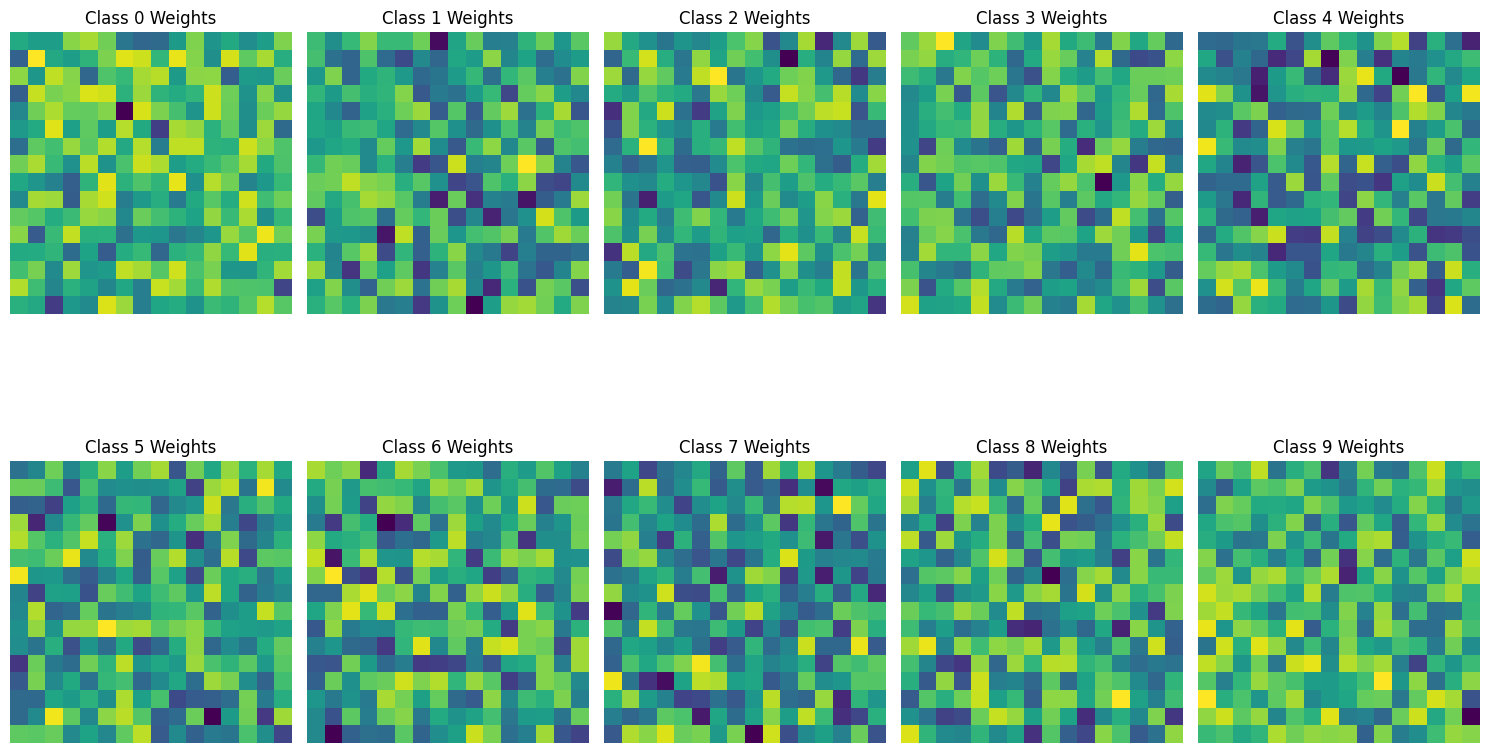

Weight visualization complete


In [16]:
# Visualize weights
visualize_weights(model)

---

## Reflection and Summary

After completing the experiments above, please answer the following questions:

1. **Limitations of fully connected networks:** The test accuracy of the fully connected neural network on CIFAR10 is about 50%, far below that of convolutional neural networks (which can reach 90%+). Analyze the reasons — what critical information do fully connected networks lose when processing image data?

2. **Softmax and Cross-Entropy conflict:** In this experiment, the last layer of the network uses a Softmax activation, while the loss function uses CrossEntropyLoss (which internally includes Softmax). What problems does this cause? If you remove the Softmax layer from the network, how would the training results change? Try modifying the code and comparing results.

3. **Role of batch normalization:** If you remove the batch normalization layers (`nn.BatchNorm1d`) from the network, what changes would occur during training? Try modifying the code and observe the differences in the training curves.

4. **Weight interpretability:** Comparing the weight visualization results with those of the first layer of a convolutional neural network (where edge detectors and other patterns are typically visible), why are the weights of a fully connected network harder to interpret?

5. **Directions for improvement:** Based on your observations in this experiment, what approaches would you take to improve CIFAR10 classification accuracy? (Hint: Consider network architecture, data preprocessing, regularization, etc.)